In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input


/Users/grittie/Workspace/University/Y4/IS/ANNML/.venv/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
a, b, c, d = 0.1, -0.5, 2.0, 1.0

x = np.linspace(-10, 10, 20000).astype(np.float32)
y = (a*x**3 + b*x**2 + c*x + d).astype(np.float32)

x_mean, x_std = float(x.mean()), float(x.std())
y_mean, y_std = float(y.mean()), float(y.std())

x_n = (x - x_mean) / x_std
y_n = (y - y_mean) / y_std

X = x_n.reshape(-1,1)
Y = y_n.reshape(-1,1)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [3]:
model = Sequential([
    Input(shape=(1,)),
    Dense(128, activation='tanh'),
    Dense(128, activation='tanh'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(
    X_train, Y_train,
    epochs=300,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

Epoch 1/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2518 - val_loss: 0.1797
Epoch 2/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - loss: 0.1807 - val_loss: 0.1715
Epoch 3/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step - loss: 0.1742 - val_loss: 0.1631
Epoch 4/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1599 - val_loss: 0.1405
Epoch 5/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1237 - val_loss: 0.0940
Epoch 6/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0695 - val_loss: 0.0452
Epoch 7/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step - loss: 0.0328 - val_loss: 0.0229
Epoch 8/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0174 - val_loss: 0.0139
Epoch 9/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0114 - val_loss: 0.0101
Epoch 10/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0084 - val_loss: 0.0077
Epoch 11/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - loss: 0.0063 - val_loss: 0.0063
Epoch 12/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - l

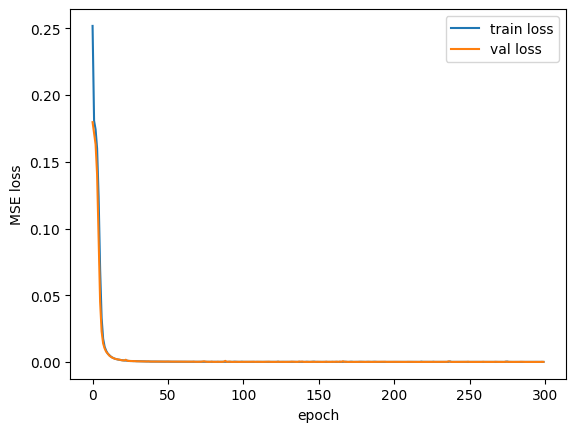

In [5]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.show()

In [6]:
pred_n = model.predict(X_test, verbose=0).flatten()
y_true_n = Y_test.flatten()

pred = pred_n * y_std + y_mean
y_true = y_true_n * y_std + y_mean

abs_err = np.abs(pred - y_true)
mse = float(np.mean((pred - y_true)**2))
mae = float(np.mean(abs_err))
max_err = float(np.max(abs_err))

print("MSE:", mse)
print("MAE:", mae)
print("Max abs error:", max_err)

MSE: 0.04029384255409241
MAE: 0.15096376836299896
Max abs error: 0.5742034912109375


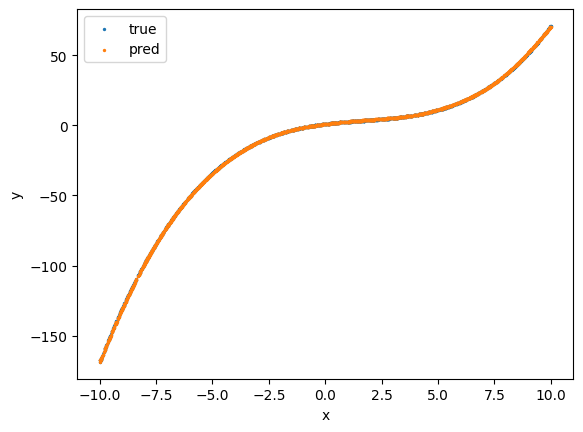

In [7]:
idx = np.random.choice(len(X_test), size=2000, replace=False)

x_plot = X_test[idx].flatten() * x_std + x_mean
y_plot_true = Y_test[idx].flatten() * y_std + y_mean

pred_n_plot = model.predict(X_test[idx], verbose=0).flatten()
y_plot_pred = pred_n_plot * y_std + y_mean

plt.scatter(x_plot, y_plot_true, s=2, label="true")
plt.scatter(x_plot, y_plot_pred, s=2, label="pred")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()